In [212]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import pennylane as qml
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pennylane.optimize import AdamOptimizer
from pennylane import numpy as pnp
import os
from sklearn.preprocessing import MinMaxScaler
import time

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [213]:
scaler = StandardScaler()
X = df.drop('target', axis=1).values
y = df['target'].values

X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_pca)
X_test_scaled = scaler.transform(X_pca)

print(pca.explained_variance_ratio_)
print(f"Total variance kept: {pca.explained_variance_ratio_.sum()*100:.1f}%")

[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]
Total variance kept: 95.2%


In [214]:
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

#INITIAL PARAMETERS
n_qubits = 10
n_layers = 25
weights = pnp.random.uniform(0, np.pi, (n_layers, n_qubits, 3), requires_grad=True)
weights_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
x = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def full_pipeline(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))
print(full_pipeline(x, weights))

def classifier(weights, bias, x):
    return full_pipeline(x, weights) 

def square_loss(labels, predictions):
    preds = qml.math.stack(predictions)
    return qml.math.sum((labels - preds) ** 2) / len(labels)

def cost(weights, bias, X, y):
    preds = [classifier(weights, bias, x) for x in X]
    return square_loss(y, preds)

def accuracy(labels, weights, bias, X):
    preds = np.sign(np.array([float(classifier(weights, bias, x)) for x in X]))
    return np.mean(np.array(labels) == preds)

label = 1.0
prediction = 0.40

opt = AdamOptimizer(stepsize=0.1)
weights = pnp.random.uniform(0, pnp.pi, weights_shape, requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

X_sample = pnp.array(X_train[:5], requires_grad=False)
y_sample = pnp.array(y_train[:5], requires_grad=False)
print(cost(weights, bias, X_sample, y_sample))

-0.01791659240509985
0.8182888709571676


In [215]:
import os

def save_run_to_csv(filename, history_list):
    """Appends data cleanly. Close the CSV tab in VS Code before running!"""
    if not history_list:
        return
        
    is_empty = True
    if os.path.exists(filename):
        with open(filename, 'r', encoding='utf-8') as f:
            first_line = f.readline()
            if first_line.strip():
                is_empty = False

    with open(filename, 'a', encoding='utf-8') as f:
        if is_empty:
            headers = ['Layers', 'Qubits', 'PCA Layers', 'Epoch', 'Total Epochs', 
                       'Cost', 'Best Cost', 'Accuracy', 'Best Accuracy', 'Time', 'Total Time']
            f.write(','.join(headers) + '\n')

        for row in history_list:
            row_values = [
                str(row["Layers"]),
                str(row["Qubits"]),
                str(row["PCA Layers"]),
                str(row["Epoch"]),
                str(row["Total Epochs"]),
                f"{row['Cost']:.4f}",
                f"{row['Best Cost']:.4f}",
                f"{row['Accuracy']:.4f}",
                f"{row['Best Accuracy']:.4f}",
                f"{row['Time']:.2f}",
                f"{row['Total Time']:.2f}"
            ]
            f.write(','.join(row_values) + '\n')

        # Clean barrier: Places the line in column 1, adds 8 commas to satisfy the 9-column grid
        f.write('=========' * 9 + '\n')
        f.flush()

In [216]:
# STRONGLY ENTANGLING LAYERS
import os
import numpy as np

X_tr = pnp.array(X_train, requires_grad=False)
Y_tr = pnp.array(2 * y_train - 1, requires_grad=False)
X_te = pnp.array(X_test, requires_grad=False)
Y_te = pnp.array(2 * y_test - 1, requires_grad=False)

# 1. Define configuration settings first
n_qubits = 10
n_layers = 3
n_pca = 10
batch_size = 35
n_epochs = 100
best_acc = 0.0
best_cost = 0.0

strong_accs = []
strong_best_acc = []
strong_costs = []
strong_best_cost = []
strong_history = []
timestamps = []

# 2. Get your shape and set requires_grad=True so they can actually learn!
weights_shape = qml.StronglyEntanglingLayers.shape(
    n_layers=n_layers, n_wires=n_qubits
)
pnp.random.seed(42)
weights = pnp.array(
    np.random.uniform(0, pnp.pi, weights_shape), requires_grad=True
)
bias = pnp.array(0.0, requires_grad=True)
opt = AdamOptimizer(0.02)

# 3. Training Loop
for epoch in range(n_epochs):
    start_time = time.perf_counter()
    idx = pnp.random.randint(0, len(X_tr), (batch_size,))
    updated_params, c = opt.step_and_cost(cost, weights, bias, X_tr[idx], Y_tr[idx])
    weights = updated_params[0]
    bias = updated_params[1]
    strong_costs.append(c)
    acc = accuracy(Y_te, weights, bias, X_te)
    end_time = time.perf_counter()
    strong_accs.append(acc)
    timestamps.append(end_time - start_time)
    print(
        f"Epoch {epoch+1:3d} | Cost: {c:.4f} | Test Acc: {acc*100:.1f}% | Time: {end_time - start_time:.2f}s")
    if acc > best_acc:
        best_acc = acc
    if c < best_cost or best_cost == 0.0:
        best_cost = c
    strong_history.append({
        "Epoch": epoch + 1,
        "Qubits": n_qubits,
        "Layers": n_layers,
        "PCA Layers": n_pca,
        "Total Epochs": n_epochs,
        "Cost": float(c),
        "Best Cost": float(best_cost),
        "Accuracy": float(acc),
        "Best Accuracy": float(best_acc),
        'Time': end_time - start_time,
        'Total Time': sum(timestamps)
        }
    )

print(f"Best Test Accuracy: {best_acc*100:.1f}%")
print(f"Best Test Cost: {best_cost:.4f}")
a_best_acc = best_acc
a_best_cost = best_cost
strong_best_acc.append(best_acc)
strong_best_cost.append(best_cost)

os.makedirs("Outputs", exist_ok=True)
master_filename = "Outputs/02_Output_StrongHistory.csv"
save_run_to_csv(master_filename, strong_history)

Epoch   1 | Cost: 0.9799 | Test Acc: 62.3% | Time: 1.49s
Epoch   2 | Cost: 0.9841 | Test Acc: 63.2% | Time: 1.56s
Epoch   3 | Cost: 1.0035 | Test Acc: 69.3% | Time: 1.54s
Epoch   4 | Cost: 0.9833 | Test Acc: 68.4% | Time: 1.56s
Epoch   5 | Cost: 0.9741 | Test Acc: 68.4% | Time: 1.60s
Epoch   6 | Cost: 0.9794 | Test Acc: 68.4% | Time: 1.49s
Epoch   7 | Cost: 1.0009 | Test Acc: 69.3% | Time: 1.56s
Epoch   8 | Cost: 0.9530 | Test Acc: 69.3% | Time: 1.57s
Epoch   9 | Cost: 0.9514 | Test Acc: 68.4% | Time: 1.54s
Epoch  10 | Cost: 0.9320 | Test Acc: 67.5% | Time: 1.57s
Epoch  11 | Cost: 0.9000 | Test Acc: 66.7% | Time: 1.61s
Epoch  12 | Cost: 0.9843 | Test Acc: 66.7% | Time: 1.50s
Epoch  13 | Cost: 0.9872 | Test Acc: 66.7% | Time: 1.54s
Epoch  14 | Cost: 0.9563 | Test Acc: 67.5% | Time: 1.59s
Epoch  15 | Cost: 0.9452 | Test Acc: 67.5% | Time: 1.60s
Epoch  16 | Cost: 0.9957 | Test Acc: 67.5% | Time: 1.51s
Epoch  17 | Cost: 0.8899 | Test Acc: 67.5% | Time: 1.63s
Epoch  18 | Cost: 0.8821 | Test

In [217]:
#BASIC ENTANGLEMENT
@qml.qnode(dev)
def full_pipeline(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
    qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

X_tr = pnp.array(X_train, requires_grad=False)
Y_tr = pnp.array(2 * y_train - 1, requires_grad=False)
X_te = pnp.array(X_test, requires_grad=False)
Y_te = pnp.array(2 * y_test - 1, requires_grad=False)

pnp.random.seed(42)
weights = pnp.array(np.random.uniform(0, np.pi, weights_shape), requires_grad=True)
weights_shape = qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_qubits)
bias = pnp.array(0.0, requires_grad=True)
opt = AdamOptimizer(0.02)

n_qubits = 10
n_layers = 8
n_pca = 10
batch_size = 25
n_epochs = 100
best_acc = 0.0
best_cost = 0.0

weights_shape = qml.BasicEntanglerLayers.shape(
    n_layers=n_layers, n_wires=n_qubits
)
pnp.random.seed(42)
weights = pnp.array(
    np.random.uniform(0, np.pi, weights_shape), requires_grad=True
)
bias = pnp.array(0.0, requires_grad=True)
opt = AdamOptimizer(0.02)

basic_accs = []
basic_best_acc = []
basic_costs = []
basic_best_cost = []
basic_history = []
timestamps = []

for epoch in range(n_epochs):
    start_time = time.perf_counter()
    idx = pnp.random.randint(0, len(X_tr), (batch_size,))
    updated_params, c = opt.step_and_cost(cost, weights, bias, X_tr[idx], Y_tr[idx])
    weights = updated_params[0]
    bias = updated_params[1]
    basic_costs.append(c)
    acc = accuracy(Y_te, weights, bias, X_te)
    end_time = time.perf_counter()
    basic_accs.append(acc)
    timestamps.append(end_time - start_time)
    print(f"Epoch {epoch+1:3d} | Cost: {c:.4f} | Test Acc: {acc*100:.1f}% | Time : {end_time - start_time:.2f}s")
    if acc > best_acc:
        best_acc = acc
    if c < best_cost or best_cost == 0.0:
        best_cost = c
    basic_history.append({
        'Epoch': epoch + 1,
        'Qubits': n_qubits,
        'Layers': n_layers,
        'PCA Layers': n_pca,
        'Total Epochs': n_epochs,
        'Cost': float(c),
        'Best Cost': float(best_cost),
        'Accuracy': float(acc),
        'Best Accuracy': float(best_acc),
        'Time': end_time - start_time,
        'Total Time': sum(timestamps)
    })
os.makedirs("Outputs", exist_ok=True)
print(f"Best Test Accuracy: {best_acc*100:.1f}%")
print(f"Best Test Cost: {best_cost:.4f}")
b_best_acc = best_acc
b_best_cost = best_cost
basic_best_acc.append(best_acc)
basic_best_cost.append(best_cost)    

os.makedirs("Outputs", exist_ok=True)
master_filename = "Outputs/02_Output_BasicHistory.csv"
save_run_to_csv(master_filename, basic_history)

Epoch   1 | Cost: 0.9979 | Test Acc: 48.2% | Time : 2.09s
Epoch   2 | Cost: 0.9955 | Test Acc: 48.2% | Time : 2.12s
Epoch   3 | Cost: 0.9916 | Test Acc: 50.0% | Time : 2.21s
Epoch   4 | Cost: 0.9981 | Test Acc: 50.0% | Time : 2.06s
Epoch   5 | Cost: 1.0040 | Test Acc: 50.0% | Time : 2.18s
Epoch   6 | Cost: 0.9970 | Test Acc: 50.0% | Time : 2.12s
Epoch   7 | Cost: 0.9908 | Test Acc: 50.0% | Time : 2.29s
Epoch   8 | Cost: 0.9965 | Test Acc: 50.0% | Time : 2.09s
Epoch   9 | Cost: 0.9803 | Test Acc: 50.0% | Time : 2.20s
Epoch  10 | Cost: 0.9945 | Test Acc: 49.1% | Time : 2.05s
Epoch  11 | Cost: 0.9918 | Test Acc: 49.1% | Time : 2.09s
Epoch  12 | Cost: 0.9876 | Test Acc: 49.1% | Time : 2.11s
Epoch  13 | Cost: 0.9925 | Test Acc: 48.2% | Time : 2.11s
Epoch  14 | Cost: 0.9945 | Test Acc: 48.2% | Time : 2.04s
Epoch  15 | Cost: 0.9739 | Test Acc: 48.2% | Time : 2.14s
Epoch  16 | Cost: 0.9721 | Test Acc: 49.1% | Time : 2.14s
Epoch  17 | Cost: 0.9917 | Test Acc: 50.9% | Time : 2.26s
Epoch  18 | Co

In [218]:
#DIFFERENT ENTANGLEMENT
@qml.qnode(dev)
def full_pipeline(x, weights):
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
    for layer in range(n_layers):
        # 1 angle per qubit per layer
        for qubit in range(n_qubits):
            qml.RY(weights[layer, qubit], wires=qubit)
            
        for q1 in range(n_qubits):
            for q2 in range(q1 + 1, n_qubits):
                qml.CNOT(wires=[q1, q2])
                
    return qml.expval(qml.PauliZ(0))

X_tr = pnp.array(X_train, requires_grad=False)
Y_tr = pnp.array(2 * y_train - 1, requires_grad=False)
X_te = pnp.array(X_test, requires_grad=False)
Y_te = pnp.array(2 * y_test - 1, requires_grad=False)

pnp.random.seed(42)
weights = pnp.array(np.random.uniform(0, np.pi, weights_shape), requires_grad=True)
weights_shape = qml.BasicEntanglerLayers.shape(n_layers=n_layers, n_wires=n_qubits)
bias = pnp.array(0.0, requires_grad=True)
opt = AdamOptimizer(0.02)

n_qubits = 10
n_layers = 6
n_pca = 10
batch_size = 25
n_epochs = 100
best_acc = 0.0
best_cost = 0.0

weights_shape = qml.BasicEntanglerLayers.shape(
    n_layers=n_layers, n_wires=n_qubits
)
pnp.random.seed(42)
weights = pnp.array(
    np.random.uniform(0, np.pi, weights_shape), requires_grad=True
)
bias = pnp.array(0.0, requires_grad=True)
opt = AdamOptimizer(0.1)

diff_accs = []
diff_best_acc = []
diff_costs = []
diff_best_cost = []
diff_history = []
time_stamps = []

for epoch in range(n_epochs):
    start_time = time.perf_counter()
    idx = pnp.random.randint(0, len(X_tr), (batch_size,))
    updated_params, c = opt.step_and_cost(cost, weights, bias, X_tr[idx], Y_tr[idx])
    weights = updated_params[0]
    bias = updated_params[1]
    diff_costs.append(c)
    acc = accuracy(Y_te, weights, bias, X_te)
    end_time = time.perf_counter()
    diff_accs.append(acc)
    time_stamps.append(end_time - start_time)
    print(f"Epoch {epoch+1:3d} | Cost: {c:.4f} | Test Acc: {acc*100:.1f}% | Time : {end_time - start_time:.2f}s")
    if acc > best_acc:
        best_acc = acc
    if c < best_cost or best_cost == 0.0:
        best_cost = c
    diff_history.append({
        'Epoch': epoch + 1,
        'Qubits': n_qubits,
        'Layers': n_layers,
        'PCA Layers': n_pca,
        'Total Epochs': n_epochs,
        'Cost': float(c),
        'Best Cost': float(best_cost),
        'Accuracy': float(acc),
        'Best Accuracy': float(best_acc),
        'Time': end_time - start_time,
        'Total Time': sum(time_stamps)
    })
print(f"Best Test Accuracy: {best_acc*100:.1f}%")
print(f"Best Test Cost: {best_cost:.4f}")
c_diff_acc = best_acc
b_best_cost = best_cost
diff_best_acc.append(best_acc)
diff_best_cost.append(best_cost)    

os.makedirs("Outputs", exist_ok=True)
master_filename = "Outputs/02_Output_DiffHistory.csv"
save_run_to_csv(master_filename, diff_history)

Epoch   1 | Cost: 1.0990 | Test Acc: 43.9% | Time : 3.65s
Epoch   2 | Cost: 1.0192 | Test Acc: 41.2% | Time : 3.69s
Epoch   3 | Cost: 0.9801 | Test Acc: 47.4% | Time : 3.66s
Epoch   4 | Cost: 0.9983 | Test Acc: 54.4% | Time : 3.62s
Epoch   5 | Cost: 0.9814 | Test Acc: 58.8% | Time : 3.74s
Epoch   6 | Cost: 1.0020 | Test Acc: 60.5% | Time : 3.65s
Epoch   7 | Cost: 0.9511 | Test Acc: 59.6% | Time : 3.58s
Epoch   8 | Cost: 0.9273 | Test Acc: 63.2% | Time : 3.65s
Epoch   9 | Cost: 0.8838 | Test Acc: 68.4% | Time : 3.63s
Epoch  10 | Cost: 0.7452 | Test Acc: 68.4% | Time : 3.65s
Epoch  11 | Cost: 0.8094 | Test Acc: 63.2% | Time : 3.63s
Epoch  12 | Cost: 0.8059 | Test Acc: 63.2% | Time : 3.66s
Epoch  13 | Cost: 0.7803 | Test Acc: 63.2% | Time : 3.63s
Epoch  14 | Cost: 0.7795 | Test Acc: 64.0% | Time : 3.62s
Epoch  15 | Cost: 0.8616 | Test Acc: 64.9% | Time : 3.65s
Epoch  16 | Cost: 1.1384 | Test Acc: 66.7% | Time : 3.66s
Epoch  17 | Cost: 0.6242 | Test Acc: 66.7% | Time : 3.59s
Epoch  18 | Co

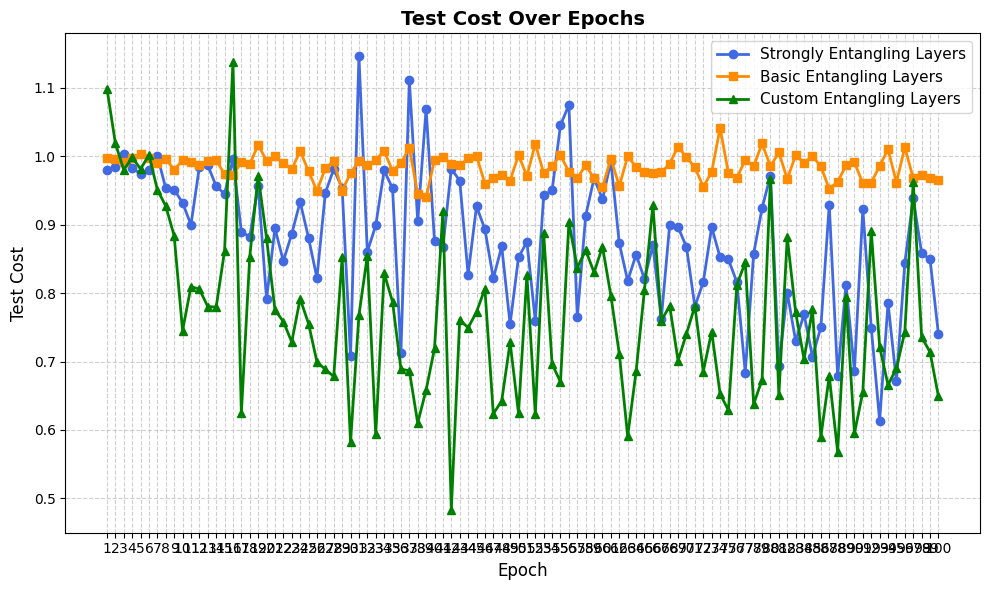

In [219]:
fig, ax = plt.subplots(figsize=(10, 6))

# Use the pre-existing lists tracking accuracy history
epochs = range(1, len(strong_accs) + 1)
ax.plot(epochs, strong_costs, marker='o', linewidth=2, label='Strongly Entangling Layers', color='royalblue')
ax.plot(epochs, basic_costs, marker='s', linewidth=2, label='Basic Entangling Layers', color='darkorange')
ax.plot(epochs, diff_costs, marker='^', linewidth=2, label='Custom Entangling Layers', color='green')

# Formatting the plot
ax.set_title('Test Cost Over Epochs', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test Cost', fontsize=12)

# Ensure the x-axis displays integer ticks for each epoch (e.g., 1, 2, 3)
ax.set_xticks(epochs)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

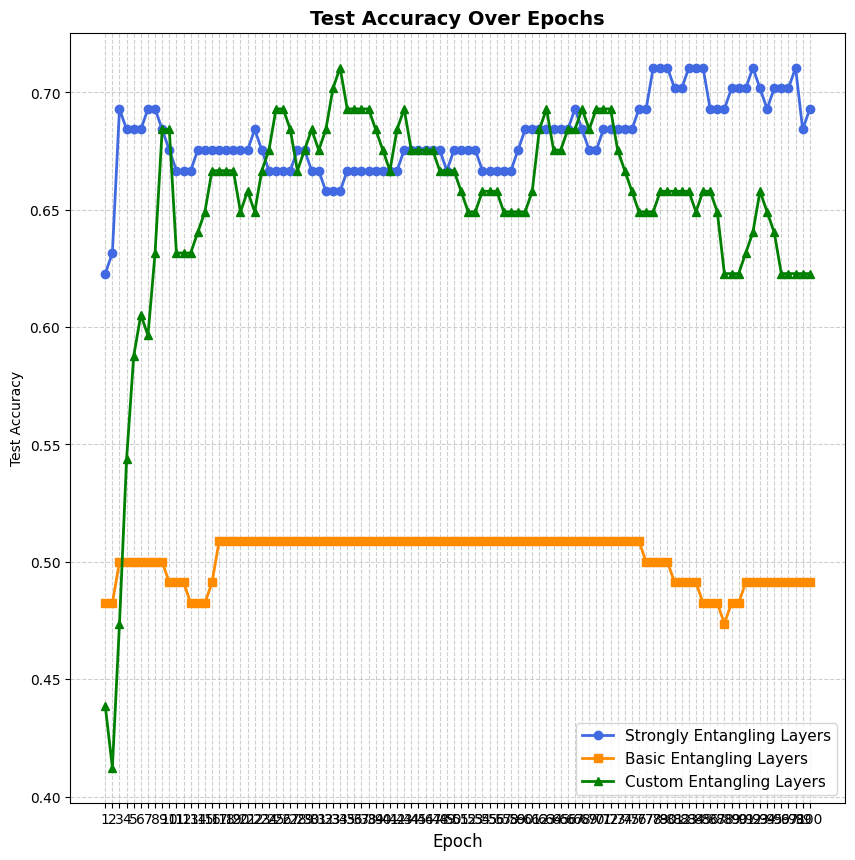

In [220]:
fig, ax = plt.subplots(figsize=(10, 10))

# Use the pre-existing lists tracking accuracy history
epochs = range(1, len(strong_accs) + 1)
ax.plot(epochs, strong_accs, marker='o', linewidth=2, label='Strongly Entangling Layers', color='royalblue')
ax.plot(epochs, basic_accs, marker='s', linewidth=2, label='Basic Entangling Layers', color='darkorange')
ax.plot(epochs, diff_accs, marker='^', linewidth=2, label='Custom Entangling Layers', color='green')

# Formatting the plot
ax.set_title('Test Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=10)

# Ensure the x-axis displays integer ticks for each epoch (e.g., 1, 2, 3)
ax.set_xticks(epochs)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

plt.show()

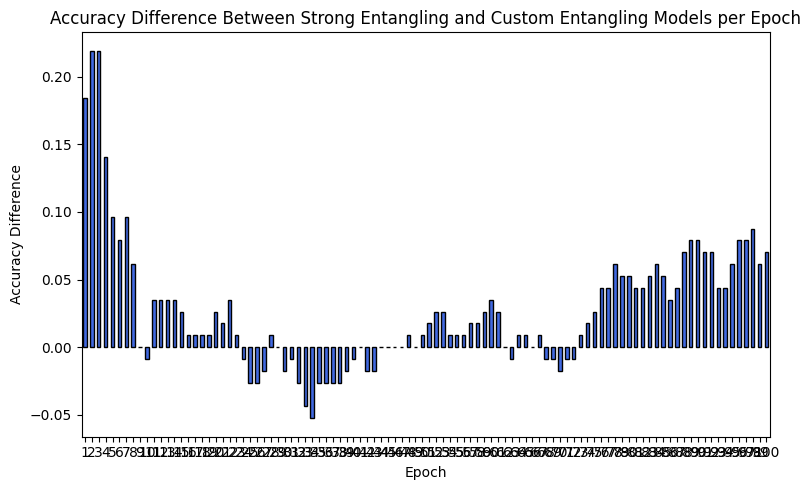

In [221]:
acc_diff = pd.Series(np.array(strong_accs) - np.array(diff_accs))

fig, ax = plt.subplots(figsize=(8, 5))
acc_diff.plot(kind='bar', ax=ax, color='royalblue', edgecolor='black')

ax.set_title('Accuracy Difference Between Strong Entangling and Custom Entangling Models per Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy Difference')

# Change x-axis labels from 0,1,2,3,4 to 1,2,3,4,5
ax.set_xticklabels([f"{i+1}" for i in range(len(acc_diff))], rotation=0)

plt.tight_layout()
plt.show()